In [1]:
# 관련 모듈과 라이브러리 import하기

# nn: 신경망 만들 때 쓰는 기본 도구들 (레이어, 활성화 함수 등)
import torch.nn as nn

# torch: 텐서 다루고 GPU 쓸 수 있게 해준다
import torch 

# datasets: 유명한 데이터셋 쉽게 다운받게 해줌
from torchvision import datasets

# transforms: 이미지를 모델이 먹을 수 있게 변환해줌(텐서로 변환하고 정규화)
from torchvision import transforms

# DataLoader: 데이터를 불러오는 애
from torch.utils.data import DataLoader

# numpy: 숫자 계산할 때 쓰는 라이브러리
import numpy as np

# optim: 모델을 학습시키는 최적화 알고리즘들 (경사하강법 등)
import torch.optim as optim 

# plt: 그래프 그리고 이미지 보여주는 애
import matplotlib.pyplot as plt

# 모델 클래스 불러오기 (models.py 파일에서)
from models import CNN, FullyConnectNN

In [2]:
# 추가 모델 정의 (ResNet, VGG, MobileNet)
import torchvision.models as models

class ResNet18_CIFAR(nn.Module):
    """ResNet18"""
    def __init__(self, num_classes=100):
        super(ResNet18_CIFAR, self).__init__()
        self.resnet = models.resnet18(weights=None)
        # CIFAR는 32x32 작은 이미지라서 첫 conv layer 수정
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # MaxPool 제거
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.resnet(x)

class ResNet50_CIFAR(nn.Module):
    """ ResNet50 (더 깊음)"""
    def __init__(self, num_classes=100):
        super(ResNet50_CIFAR, self).__init__()
        self.resnet = models.resnet50(weights=None)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.resnet(x)

class VGG16_CIFAR(nn.Module):
    """VGG16"""
    def __init__(self, num_classes=100):
        super(VGG16_CIFAR, self).__init__()
        self.vgg = models.vgg16(weights=None)
        self.vgg.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(512, num_classes),
        )
    
    def forward(self, x):
        return self.vgg(x)

class MobileNetV2_CIFAR(nn.Module):
    """MobileNetV2 (가벼움!)"""
    def __init__(self, num_classes=100):
        super(MobileNetV2_CIFAR, self).__init__()
        self.mobilenet = models.mobilenet_v2(weights=None)
        self.mobilenet.classifier[1] = nn.Linear(self.mobilenet.last_channel, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

# 추가 모델 정의 완료! (ResNet18, ResNet50, VGG16, MobileNetV2)

In [3]:
# CIFAR-100 데이터셋 다운로드 및 불러오기

# 데이터셋을 저장할 경로 넣을 변수
download_root = 'CIFAR100_data/'

# compose : 리스트 안에 들어있는 여러 전처리를 순서대로 적용할 수 있게 해줌
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# RGB 3채널 각각에 대해 평균 0.5, 표준편차 0.5로 정규화
# 학습용 데이터셋
dataset1 = datasets.CIFAR100(root=download_root, 
                          train = True, 
                          # 이미지를 PyTorch FloatTensor로 변환
                          # 왜냐면 딥러닝 모델은 텐서 형태의 데이터만 알아먹음!
                          # 픽셀값을 0~1 범위로 정규화하기!
                          transform = transformations,
                          download=True)

# 테스트용 데이터셋
dataset2 = datasets.CIFAR100(root=download_root,
                            # 학습용이 아니므로 이번에는 False!
                            train = False, 
                            transform = transformations,
                            download=True)

100%|██████████| 169M/169M [00:16<00:00, 10.1MB/s] 


Extracting CIFAR100_data/cifar-100-python.tar.gz to CIFAR100_data/
Files already downloaded and verified


In [4]:
# Batch 사이즈 설정하기 (한 번에 얼마나 많은 데이터 처리할지)
batch = 64
# DataLoader로 데이터셋 불러오기
train_Loader = DataLoader(dataset=dataset1, batch_size = batch, shuffle = True)
test_Loader = DataLoader(dataset=dataset2, batch_size = batch, shuffle = False)

In [5]:
# GPU 설정하기
# CUDA가 사용 가능하면 GPU 사용, 아니면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 중인 디바이스: {device}')

사용 중인 디바이스: cuda


In [ ]:
print(train_Loader)
Iter= iter(train_Loader) 
print(Iter) 
item_64 = next(Iter) #64개의 이미지랑 레이블 셋 가져오기
print(item_64)
image, label = item_64
print(item_64[0].shape)
print(image.shape)
print(label.shape)

[tensor([[[[ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9843,  0.9922,  ...,  0.9922,  0.9922,  0.9922],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          ...,
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000]],

         [[ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9843,  0.9922,  ...,  0.9922,  0.9922,  0.9922],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          ...,
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000]],

         [[ 1.0000,  0.9922,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.9843, 

In [7]:
# 정규화
# 예시 : 동료평가 
# 나 : 잘한친구 10점 못한친구 8점
# 친구 : 잘한친구 4점 / 못한친구 2점
# 이미지 : 밝고 쨍함 = 255에 가까움, 어두운 = 0에 가까움
# -m / 표준편차 => 정규화

In [ ]:
# Loss function과 optimizer 설정하기

# 모델 생성하기 (100개 클래스로 설정)
model = ResNet50_CIFAR(num_classes=100)
# 모델을 GPU로 이동 (GPU 사용 가능할 경우)
model = model.to(device)
# 모델이 가진 모든 파라미터의 기울기를 0으로 초기화
model.zero_grad()
# 손실 함수로 CrossEntropyLoss 사용 (분류 문제에 적합한 것!)
loss_function = nn.CrossEntropyLoss()
# CIFAR-100은 어려워서 Adam optimizer + 낮은 학습률 사용!
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [ ]:
# epoch 설정하기

# 5만장을 64개씩 나누면 총 몇 번의 배치가 필요한지 계산
# 배치 사이즈 = 64 -> 총 782번의 배치 필요
total_batch = len(train_Loader) # DataLoader 형식정의 안에 __len__ 메서드가 있어서 길이(배치 개수) 반환
print(total_batch) #782인 이유 = 50000 / 64 = 781.25 -> 올림해서 782
epochs = np.arange(1, 31)  # CIFAR-100은 더 많이 학습해야 함 (30 epoch)

782


In [10]:
# CIFAR-100 Dataset Training and Inference

loss_list = [] # Loss값 저장할 리스트
accuracy_list = [] # 정확도 저장할 리스트

for epoch in epochs:
    cost = 0 # epoch 당 Loss 초기화

    for images, labels in train_Loader:
        # 데이터를 GPU로 이동
        images = images.to(device)
        labels = labels.to(device)
        
        # CNN 모델은 이미지 형태 그대로 사용 (batch, 3, 32, 32)
        
        optimizer.zero_grad() # gradient 초기화

        #forward
        
        # 모델에 이미지 넣고 예측값 얻기
        pred = model.forward(images)  
        loss = loss_function(pred, labels) # 예측값과 실제값 비교해서 Loss 계산

        #backward

        #backpropagation
        loss.backward() # Loss 기준으로 모델 파라미터들의 기울기 계산

        # Update_weights
        optimizer.step() # 계산된 기울기로 모델 파라미터 업데이트

        cost += loss # 이번 배치의 Loss를 epoch의 총 Loss에 더하기
    
    print(f"Epoch {epoch}/{epochs[-1]} - Loss: {(cost / total_batch).item():.4f}")

# 이제 학습된 모델로 테스트 데이터셋에 대해 Inference해보기
# 맞은 것과 틀린 것 저장할 리스트
correct_examples = []
wrong_examples = []

with torch.no_grad(): # 기울기 계산 안함 (추론 모드니까!)
    total = 0 # 전체 샘플 수 초기화
    correct = 0 # 맞춘 샘플 수 초기화

    for images, labels in test_Loader:
        # 데이터를 GPU로 이동
        images = images.to(device)
        labels = labels.to(device)
        
        # CNN 모델은 이미지 형태 그대로 사용 (batch, 3, 32, 32)
        # FullyConnectNN 모델은 1차원 벡터로 변환 필요: images = images.reshape(-1, 32*32*3)

        outputs = model.forward(images) # 모델에 이미지 넣고 예측값 얻기
        # 가장 높은 확률 가진 클래스를 선택하기 
        # ([1,100]에서 100개의 값을 쭉 봐서 가장 높은 값과 인덱스 가져오기)
        _, predicted = torch.max(outputs.data, 1) 

        total +=labels.size(0)  # 전체 샘플 수 업데이트
        correct += (predicted == labels).sum() # 맞춘 샘플 수 업데이트
        
        # 시각화를 위해 맞은 거랑 틀린 거 5개씩 모으기
        # 아직 5개씩 안 모았으면 for문 실행
        if len(correct_examples) < 5 or len(wrong_examples) < 5:
            # 각 배치의 모든 샘플에 대해 확인 
            for i in range(len(labels)):
                # 맞을 경우 AND 아직 5개 안 모았으면 저장
                if len(correct_examples) < 5 and predicted[i] == labels[i]:
                    # 시각화를 위해 CPU로 이동
                    correct_examples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))
                # 틀렸을 경우 AND 아직 5개 안 모았으면 저장
                elif len(wrong_examples) < 5 and predicted[i] != labels[i]:
                    # 시각화를 위해 CPU로 이동
                    wrong_examples.append((images[i].cpu(), labels[i].item(), predicted[i].item()))

    avg_cost = cost / total_batch # epoch 당 평균 Loss 계산
    accuracy = 100 * correct / total # 정확도 계산

    # detach = grad_fn, require_grad 등 계산 그래프에서 분리
    # numpy() = 텐서를 넘파이 배열로 변환
    loss_list.append(avg_cost.detach().cpu().numpy()) # CPU로 이동 후 numpy 변환
    accuracy_list.append(accuracy) # 정확도 리스트에 추가

print(f"\n최종 결과 - Loss: {avg_cost.item():.4f}, Accuracy: {accuracy.item():.2f}%")

Epoch 1/10 - Loss: 4.4148
Epoch 2/10 - Loss: 3.9158
Epoch 3/10 - Loss: 3.6389
Epoch 4/10 - Loss: 3.4053
Epoch 5/10 - Loss: 3.1984
Epoch 6/10 - Loss: 3.0074
Epoch 7/10 - Loss: 2.8370
Epoch 8/10 - Loss: 2.6714
Epoch 9/10 - Loss: 2.5141
Epoch 10/10 - Loss: 2.3547

최종 결과 - Loss: 2.3547, Accuracy: 29.93%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.9607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85882354..0.92941177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.9529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..0.4901961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6313726..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..0.81960785].

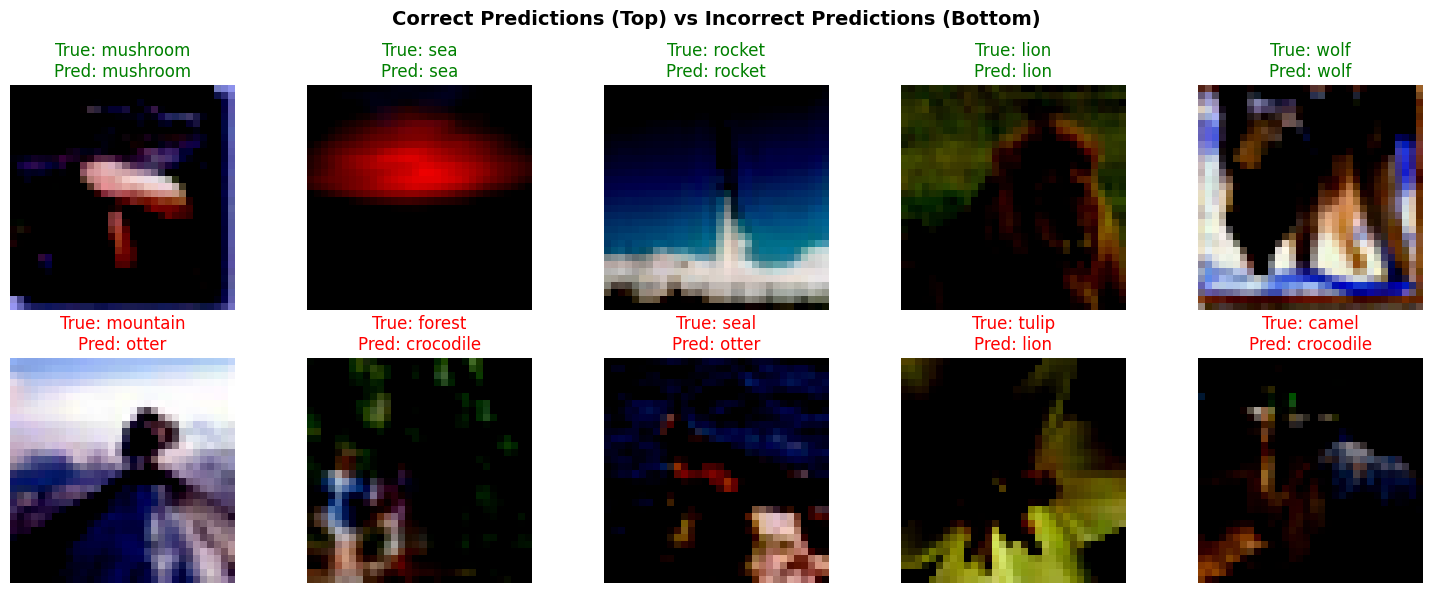

In [11]:
# 예측 결과 시각화하기

# CIFAR-100 클래스 이름 (100개)
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 2행 5열의 서브플롯 생성
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) # figsize는 15인치 x 6인치 크기

# 맞은 예측 5개
# i = 번호, img = 이미지, true_label = 정답 레이블, pred_label = 예측 레이블
for i, (img, true_label, pred_label) in enumerate(correct_examples):
    # 이미지 출력
    # axes[0,i] = 첫번째 행, i번째 열
    # permute(1, 2, 0) = (C, H, W) -> (H, W, C) 형태로 변환 (matplotlib가 요구하는 형식)
    img_show = img.permute(1, 2, 0)
    axes[0, i].imshow(img_show) 
    axes[0, i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', color='green')
    # axis('off') = 축 숨기기
    axes[0, i].axis('off')

# 틀린 예측 5개
for i, (img, true_label, pred_label) in enumerate(wrong_examples):
    img_show = img.permute(1, 2, 0)
    axes[1, i].imshow(img_show)
    axes[1, i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', color='red')
    axes[1, i].axis('off')

plt.suptitle('Correct Predictions (Top) vs Incorrect Predictions (Bottom)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# 모델 파라미터(가중치, bias) 저장
torch.save(model.state_dict(), 'cifar100_cnn_model.pth')  
